# Inspect ESP Projection .pt Files

Set `data_dir` or `pt_path` below, then run the cells to load and visualize projections and rotations.

In [6]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import torch

In [7]:
# Set either data_dir (directory with .pt files) or pt_path (specific .pt file).
data_dir = Path("output/smoketest")
pt_path = None  # Path("/path/to/7t54_esp_projections_10.pt")

if pt_path is None:
    if not data_dir.exists():
        raise FileNotFoundError(f"data_dir not found: {data_dir.resolve()}")
    pt_files = sorted(data_dir.glob("*.pt"))
    if not pt_files:
        raise FileNotFoundError(f"No .pt files found in {data_dir.resolve()}")
    pt_path = pt_files[0]

pt_path = Path(pt_path)
print(f"Loading: {pt_path}")

Loading: output/smoketest/7t54_esp_projections_100.pt


In [8]:
data = torch.load(pt_path, map_location="cpu")
print("Keys:", list(data.keys()))

projections = data["projections"]
rotations = data["rotations"]
meta = data.get("meta")

print("projections shape:", tuple(projections.shape))
print("rotations shape:", tuple(rotations.shape))
if meta is not None:
    print("meta:")
    print(json.dumps(meta, indent=2))
else:
    json_path = pt_path.with_suffix(".json")
    if json_path.exists():
        print("meta (from json):")
        print(json_path.read_text())

Keys: ['projections', 'rotations', 'meta']
projections shape: (100, 164, 164)
rotations shape: (100, 3, 3)
meta:
{
  "pdb_id": "7t54",
  "pdb_path": "tests/7t54.pdb",
  "num_rotations": 100,
  "projection_axis": "z",
  "voxel_size": 1.0,
  "resolution": 2.0,
  "atom_batch_size": 1024,
  "bfactor_override": null,
  "atomic_radius": 0.5,
  "device": "cuda:0",
  "lattice": {
    "grid_dimensions": [
      164,
      164,
      1
    ],
    "voxel_sizes": [
      1.0,
      1.0,
      162.62046813964844
    ],
    "left_bottom": [
      73.009033203125,
      73.03265380859375,
      186.96070861816406
    ],
    "right_upper": [
      236.009033203125,
      236.03265380859375,
      186.96070861816406
    ],
    "center": [
      154.509033203125,
      154.53265380859375,
      186.96070861816406
    ],
    "radius": 71.31023406982422,
    "padding": 10.0,
    "sublattice_radius": 14.0,
    "projection_axis": 2,
    "projection_depth": 162.62046813964844,
    "collapse_projection_axis":

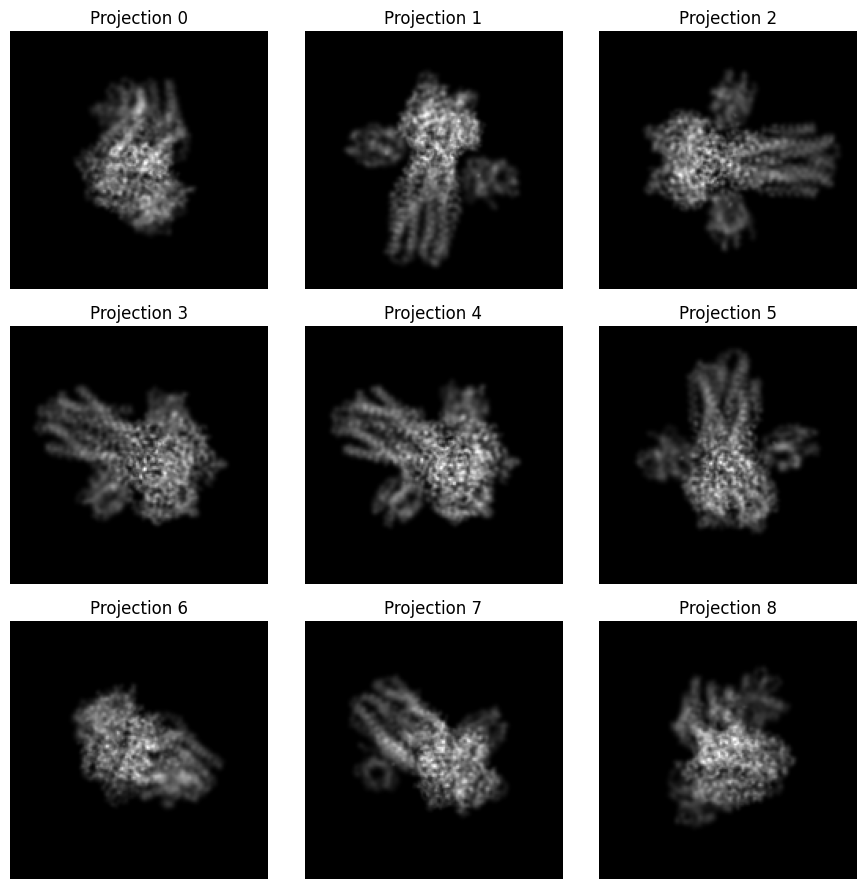

In [20]:
# Visualize a 3x3 grid of projections
num = min(9, projections.shape[0])
fig, axes = plt.subplots(3, 3, figsize=(9, 9))
axes = axes.flatten()

for i, ax in enumerate(axes):
    if i < num:
        ax.imshow(projections[i].numpy(), cmap="gray", origin="lower")
        ax.set_title(f"Projection {i}")
    ax.axis("off")

plt.tight_layout()
plt.show()


In [10]:
# Inspect a rotation matrix
idx = 0
rot = rotations[idx]
print(rot)
print("determinant:", torch.det(rot).item())
print("orthonormal check (R^T R):")
print((rot.T @ rot).numpy())

tensor([[-0.8224, -0.0045, -0.5688],
        [ 0.1292, -0.9753, -0.1791],
        [-0.5540, -0.2208,  0.8027]])
determinant: 0.9999997019767761
orthonormal check (R^T R):
[[ 9.9999976e-01  2.0148171e-08 -1.5275103e-07]
 [ 2.0148171e-08  9.9999958e-01 -5.2622802e-08]
 [-1.5275103e-07 -5.2622802e-08  9.9999994e-01]]
